<a href="https://colab.research.google.com/github/Bachbean/Predicting-the-Unpredictable/blob/main/scripts/CM1_lyapunov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of rows: 10000

MAXIMUM LYAPUNOV EXPONENTS

Column 1
tau = 108
m = 4
lambda_max = 0.01079879
R^2 = 0.929572

Column 2
tau = 108
m = 4
lambda_max = 0.01178852
R^2 = 0.809662

Column 3
tau = 108
m = 4
lambda_max = 0.01558955
R^2 = 0.770159

Column 4
tau = 108
m = 4
lambda_max = 0.01082961
R^2 = 0.897031

CONSISTENCY SUMMARY
Mean lambda: 0.012251619122221235
Minimum lambda: 0.010798794440522777
Maximum lambda: 0.015589553105675759
Standard deviation: 0.0022722295350835146
Range relative to mean: 39.10%


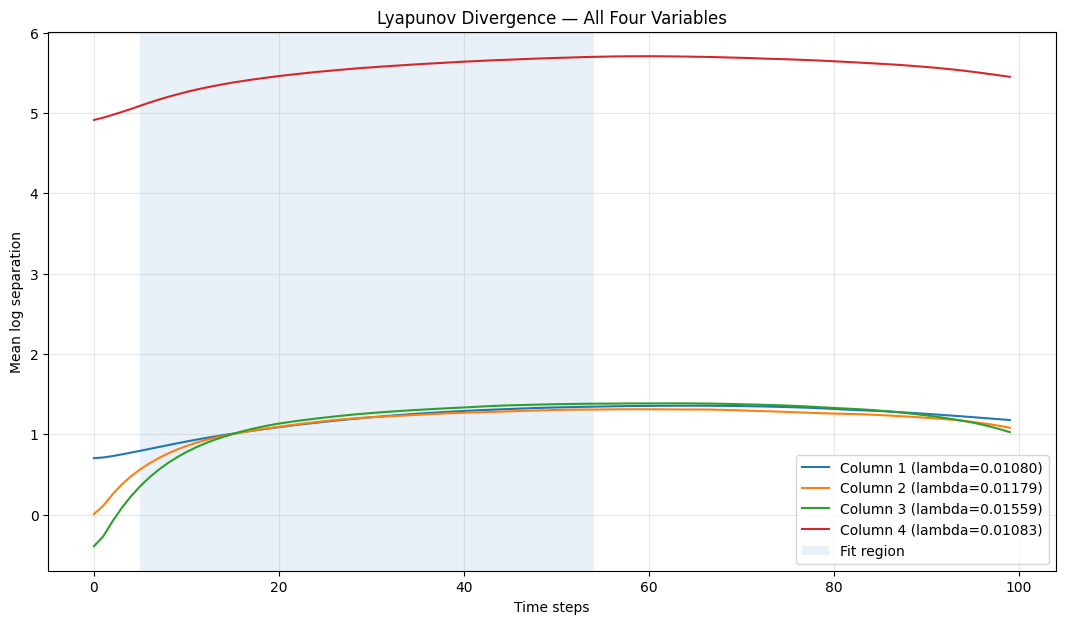

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import requests

from io import StringIO
from scipy.spatial import cKDTree


# ============================================================
# 1. LOAD CSV FROM GITHUB
# ============================================================

url = "https://raw.githubusercontent.com/Bachbean/Predicting-the-Unpredictable/refs/heads/main/scripts/CM1_all_vars_30s.csv"

response = requests.get(url)
response.raise_for_status()


data_all = np.loadtxt(
    StringIO(response.text),
    delimiter=",",
    dtype=np.float64,
    skiprows=1
)

data = data_all[:10000]


if data.ndim != 2 or data.shape[1] != 4:

    raise ValueError(
        "Expected exactly four comma-separated numerical columns."
    )


# ============================================================
# 2. SPLIT INTO FOUR ARRAYS
# ============================================================

data1 = data[:, 0]
data2 = data[:, 1]
data3 = data[:, 2]
data4 = data[:, 3]


all_data = [
    data1,
    data2,
    data3,
    data4
]


print("Number of rows:", len(data))


# ============================================================
# 3. ENTER TAU VALUES FROM AMI
# ============================================================

# Replace these with the actual four tau values
# you found from the AMI program.

tau_by_column = [
    108,
    108,
    108,
    108
]


# ============================================================
# 4. EMBEDDING DIMENSION
# ============================================================

# Use common embedding dimension m = 4
# for comparison across all four observables.

m = 4


# ============================================================
# 5. LYAPUNOV SETTINGS
# ============================================================

# Number of future samples over which divergence is followed
max_k = 100


# Linear region of the mean log-divergence curve.
#
# Use the range that visually appears straight.
# These are example values based on your earlier analysis.

fit_start = 5
fit_end = 55


# Sampling interval.
#
# Leave at 1.0 if lambda should be measured "per sample".
dt = 1.0


# ============================================================
# 6. DELAY EMBEDDING FUNCTION
# ============================================================

def delay_embed(
    series,
    m,
    tau
):

    N = (
        len(series)
        -
        (m - 1) * tau
    )


    if N <= 0:

        raise ValueError(
            "Embedding parameters are too large."
        )


    X = np.empty(
        (N, m)
    )


    for j in range(m):

        X[:, j] = series[
            j * tau:
            j * tau + N
        ]


    return X


# ============================================================
# 7. MAXIMUM LYAPUNOV EXPONENT FUNCTION
# ============================================================

def calculate_lyapunov(
    series,
    tau,
    m,
    theiler_window,
    max_k,
    fit_start,
    fit_end,
    dt=1.0
):

    # --------------------------------------------------------
    # Reconstruct state space
    # --------------------------------------------------------

    X = delay_embed(
        series,
        m,
        tau
    )


    usable_points = (
        len(X)
        -
        max_k
    )


    if usable_points <= 10:

        raise ValueError(
            "Not enough points for Lyapunov analysis."
        )


    X_search = X[
        :usable_points
    ]


    # --------------------------------------------------------
    # Build nearest-neighbor tree
    # --------------------------------------------------------

    tree = cKDTree(
        X_search
    )


    number_candidates = min(

        max(
            50,
            2 * theiler_window + 20
        ),

        usable_points

    )


    distances, indices = tree.query(
        X_search,
        k=number_candidates
    )


    # --------------------------------------------------------
    # Find nearest spatial neighbor while excluding
    # temporally nearby points
    # --------------------------------------------------------

    nearest_neighbor = np.full(
        usable_points,
        -1,
        dtype=int
    )


    for i in range(
        usable_points
    ):

        for distance, candidate in zip(
            np.atleast_1d(
                distances[i]
            ),
            np.atleast_1d(
                indices[i]
            )
        ):

            if candidate >= usable_points:
                continue


            # Theiler window
            if (
                abs(candidate - i)
                <=
                theiler_window
            ):

                continue


            if (
                not np.isfinite(distance)
                or
                distance <= 0
            ):

                continue


            nearest_neighbor[i] = candidate

            break


    # --------------------------------------------------------
    # Keep only valid pairs
    # --------------------------------------------------------

    reference_indices = np.where(
        nearest_neighbor >= 0
    )[0]


    neighbor_indices = (
        nearest_neighbor[
            reference_indices
        ]
    )


    if len(reference_indices) < 10:

        raise ValueError(
            "Too few valid nearest-neighbor pairs."
        )


    # --------------------------------------------------------
    # Follow divergence through time
    # --------------------------------------------------------

    mean_log_divergence = np.full(
        max_k,
        np.nan
    )


    for k in range(max_k):

        A = X[
            reference_indices + k
        ]


        B = X[
            neighbor_indices + k
        ]


        separation = np.linalg.norm(
            A - B,
            axis=1
        )


        valid = (
            np.isfinite(separation)
            &
            (separation > 0)
        )


        if np.any(valid):

            mean_log_divergence[k] = np.mean(
                np.log(
                    separation[valid]
                )
            )


    # --------------------------------------------------------
    # Fit linear divergence region
    # --------------------------------------------------------

    k_values = np.arange(
        max_k
    )


    fit_mask = (
        (k_values >= fit_start)
        &
        (k_values < fit_end)
        &
        np.isfinite(
            mean_log_divergence
        )
    )


    x_fit = (
        k_values[fit_mask]
        *
        dt
    )


    y_fit = (
        mean_log_divergence[
            fit_mask
        ]
    )


    if len(x_fit) < 3:

        raise ValueError(
            "Not enough points in fit interval."
        )


    slope, intercept = np.polyfit(
        x_fit,
        y_fit,
        1
    )


    predicted = (
        slope * x_fit
        +
        intercept
    )


    # --------------------------------------------------------
    # Calculate R^2
    # --------------------------------------------------------

    ss_res = np.sum(
        (
            y_fit
            -
            predicted
        ) ** 2
    )


    ss_tot = np.sum(
        (
            y_fit
            -
            np.mean(y_fit)
        ) ** 2
    )


    if ss_tot > 0:

        r_squared = (
            1
            -
            ss_res / ss_tot
        )

    else:

        r_squared = np.nan


    return (
        slope,
        r_squared,
        mean_log_divergence,
        k_values
    )


# ============================================================
# 8. CALCULATE LYAPUNOV EXPONENT FOR ALL FOUR COLUMNS
# ============================================================

lambda_values = []

r2_values = []

divergence_curves = []


for column in range(4):

    series = all_data[column]

    tau = tau_by_column[column]


    # Use each column's tau as its Theiler window
    theiler_window = tau


    (
        lambda_max,
        r_squared,
        divergence,
        k_values
    ) = calculate_lyapunov(

        series=series,

        tau=tau,

        m=m,

        theiler_window=theiler_window,

        max_k=max_k,

        fit_start=fit_start,

        fit_end=fit_end,

        dt=dt

    )


    lambda_values.append(
        lambda_max
    )


    r2_values.append(
        r_squared
    )


    divergence_curves.append(
        divergence
    )


# ============================================================
# 9. PRINT RESULTS
# ============================================================

print("\n======================================")
print("MAXIMUM LYAPUNOV EXPONENTS")
print("======================================")


for column in range(4):

    print(
        f"\nColumn {column + 1}"
    )


    print(
        f"tau = "
        f"{tau_by_column[column]}"
    )


    print(
        f"m = "
        f"{m}"
    )


    print(
        f"lambda_max = "
        f"{lambda_values[column]:.8f}"
    )


    print(
        f"R^2 = "
        f"{r2_values[column]:.6f}"
    )


# ============================================================
# 10. SUMMARY OF AGREEMENT
# ============================================================

lambda_values = np.asarray(
    lambda_values
)


print("\n======================================")
print("CONSISTENCY SUMMARY")
print("======================================")


print(
    "Mean lambda:",
    np.mean(lambda_values)
)


print(
    "Minimum lambda:",
    np.min(lambda_values)
)


print(
    "Maximum lambda:",
    np.max(lambda_values)
)


print(
    "Standard deviation:",
    np.std(
        lambda_values,
        ddof=1
    )
)


relative_spread = (

    (
        np.max(lambda_values)
        -
        np.min(lambda_values)
    )

    /

    np.mean(lambda_values)

) * 100


print(
    f"Range relative to mean: "
    f"{relative_spread:.2f}%"
)


# ============================================================
# 11. PLOT ALL FOUR LOG-DIVERGENCE CURVES
# ============================================================

plt.figure(
    figsize=(13, 7)
)


for column in range(4):

    plt.plot(

        k_values * dt,

        divergence_curves[column],

        label=(
            f"Column {column + 1} "
            f"(lambda={lambda_values[column]:.5f})"
        )

    )


plt.axvspan(
    fit_start * dt,
    (fit_end - 1) * dt,
    alpha=0.1,
    label="Fit region"
)


plt.xlabel(
    "Time steps"
    if dt == 1.0
    else
    "Time"
)


plt.ylabel(
    "Mean log separation"
)


plt.title(
    "Lyapunov Divergence — All Four Variables"
)


plt.grid(
    alpha=0.3
)


plt.legend()


plt.show()